## **K-Nearest Neighbors (K-Vizinhos mais Próximos)**
O **KNN** é um algoritmo de **aprendizado supervisionado** usado em problemas de **classificação** e **regressão**.

Considere um conjunto de observações:

$$
\mathcal{D} = \{(\mathbb{x}_i, y_{i})\}_{i=1}^{N}
$$
    
onde

$$
\mathbb{x}_i =
\begin{bmatrix}
  x_{i1} \\ x_{i2} \\ \vdots \\ x_{id}
  \end{bmatrix} \in \mathbb{R}^{D}
$$

Dependendo do tipo de problema, temos:

#### **Classificação**

O valor de $y_i$ é uma classe, ou seja:

$$
y_i \in \mathcal{C} = \{c_i\}_{i=1}^{m}, \quad m \leq N
$$

onde $\mathcal{C}$ é o conjunto das classes.

#### **Regressão**

O valor de $y_i$ é um valor real, ou seja:

$$
y_i \in \mathbb{R}
$$

Dado um novo vetor de atributos $\mathbb{z}$, o KNN depende de uma função de distância, $d(.,.)$, definida por:

$$
d : \mathbb{R}^{D} \times \mathbb{R}^{D} \rightarrow \mathbb{R}^{+}
$$


Normalmente, a métrica utilizada é a distância Euclidiana, dada por:

$$
d(\mathbb{z}, \mathbb{x}_i) = \sqrt{\sum_{j=1}^{D} (\mathbb{z}_{j} - \mathbb{x}_{ij})^{2}}
$$

Calculadas as distâncias de $\mathbb{z}$ e cada $\mathbb{x}_i$, ordenamos o conjunto de dados de acordo com:

$$
d(\mathbb{z}, \mathbb{x}_{(1)}) \leq d(\mathbb{z}, \mathbb{x}_{(2)}) \leq \dots \leq d(\mathbb{z}, \mathbb{x}_{(N)})
$$

Dado um $k \leq N$, definimos então a vizinhança de $\mathbb{z}$:

$$
N_k(\mathbb{z}) := \{(x_{(1)}, y_{(1)}), (x_{(2)}, y_{(2)}), \dots, (x_{(k)}, y_{(k)})\}
$$

são esses os $k$ vizinhos mais próximos.

### **KNN para Regressão**

Sendo $\hat{y} \in \mathbb{R}$, o valor que desejamos predizer, seu valor é dado por:

$$
\hat{y} = \dfrac{1}{k} \cdot \sum_{i=1}^{k} y_{(i)}
$$

onde $y_{(i)} \in N_k(\mathbb{z})$.

### **KNN para Classificação**

Sendo $\hat{y} \in \mathcal{C}$, o valor que desejamos predizer, seu valor é dado por:

$$
\hat{y} = \arg\max_{c \in \mathcal{C}} \sum_{i=1}^{k} \mathbb{I}(y_{(i)} = c)
$$

Onde $\mathbb{I}(\cdot)$ é a função indicadora definido como segue:

$$
\mathbb{I}(A) :=
\begin{cases}
1, & \text{se a condição } A \text{ é verdadeira} \\
0, & \text{caso contrário}
\end{cases}
$$

### **Implementação do KNN para problema de Classificação**

Vamos utilizar o algoritmo **K-Nearest Neighbors** para tarefa de **classificação**  no dataset [**Iris Flower Dataset**](https://scikit-learn.org/1.5/auto_examples/datasets/plot_iris_dataset.html).

#### **Pré-processamento dos dados**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (150, 4)
Shape de y: (150,)


In [ ]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y

df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (120, 4)
Teste: (30, 4)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### **Implementação do KNN para Classificação**

In [ ]:
from collections import Counter

def predict_classification(X_train, y_train, z, k):

    distances = []

    for i in range(len(X_train)):
        dist = np.sqrt(np.sum((z - X_train[i]) ** 2))
        distances.append(dist)

    distances = np.array(distances)

    neighbor_idx = np.argsort(distances)[:k]

    neighbor_labels = y_train[neighbor_idx]

    most_common = Counter(neighbor_labels).most_common(1)

    return most_common[0][0]

In [ ]:
def knn_predict(X_train, y_train, X_test, k):

    predictions = []

    for z in X_test:
        pred = predict_classification(X_train, y_train, z, k)
        predictions.append(pred)

    return np.array(predictions)

k = 5
y_pred = knn_predict(X_train, y_train, X_test, k)

accuracy = np.mean(y_pred == y_test)

print(f"Accuracy: {100 * accuracy.round(4)}%")

Accuracy: 93.33%


#### **Visualização dos dados com PCA**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train)

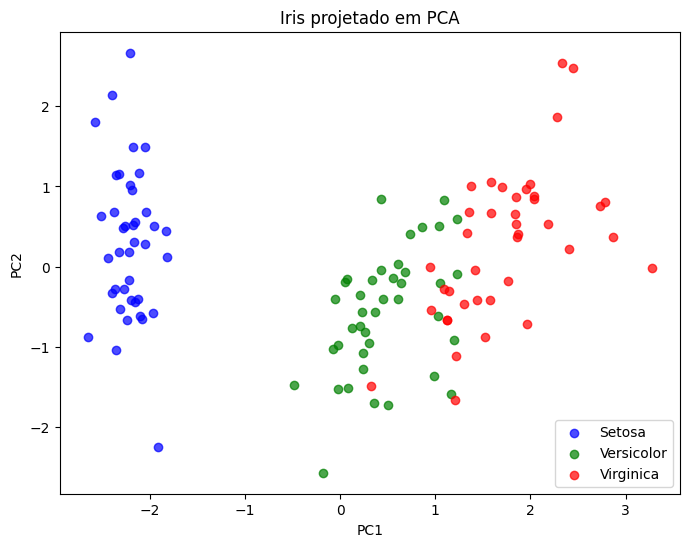

In [ ]:
plt.figure(figsize=(8,6))

colors = ['blue', 'green', 'red']
labels = ["Setosa", "Versicolor", "Virginica"]

classes = np.unique(y_train)

for i, c in enumerate(classes):

    plt.scatter(
        X_pca[y_train == c, 0],
        X_pca[y_train == c, 1],
        color=colors[i],
        label=labels[i],
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Iris projetado em PCA")
plt.legend()

plt.show()